# 深圳市二手房房价分析及预测
本项目基于深圳市多个行政区的二手房数据，分析区域、面积、户型、楼层、是否靠近地铁、是否为学区房等因素对单位面积房价的影响，并建立机器学习模型预测房源单价。项目目标是通过数据清洗、探索性数据分析和建模预测，理解深圳二手房价格差异的主要原因，并为房源估值和房地产市场分析提供量化参考。

## 数据读取与合并
- 本项目的数据由深圳多个行政区的二手房 Excel 文件组成。首先读取所有以 `szfj_` 开头的 Excel 文件，并根据文件名提取行政区信息，新增 `district` 字段。随后将所有区域数据合并为一个完整的数据集，方便后续进行统一的数据清洗、可视化分析和建模预测。

- 合并后的数据包含 $18,514$ 条房源记录和 $10$ 个字段，主要变量包括行政区、房间数、厅数、面积、楼层类型、楼层数、是否学区房、是否靠近地铁以及单位面积房价。

In [105]:
# 如果读取 .xls 文件时报错 Missing optional dependency 'xlrd'，先取消下一行注释并运行：
# !pip install xlrd

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.rcParams["font.sans-serif"] = ["SimHei", "Arial Unicode MS", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

In [106]:
# 原始 Excel 文件与 notebook 放在同一文件夹
data_path = "."

# 读取所有以 szfj_ 开头的深圳二手房数据文件
files = glob.glob(os.path.join(data_path, "szfj_*.xls"))

print("找到的文件数量：", len(files))
print(files[:5])

找到的文件数量： 10
['./szfj_luohu.xls', './szfj_pingshan.xls', './szfj_dapengxinqu.xls', './szfj_guangming.xls', './szfj_yantian.xls']


In [107]:
district_map = {
    "baoan": "宝安",
    "dapengxinqu": "大鹏新区",
    "futian": "福田",
    "guangming": "光明",
    "longgang": "龙岗",
    "longhua": "龙华",
    "luohu": "罗湖",
    "nanshan": "南山",
    "pingshan": "坪山",
    "yantian": "盐田"
}

all_data = []

for file in files:
    temp = pd.read_excel(file)
    
    # 从文件名中提取区域英文名，例如 szfj_nanshan.xls -> nanshan
    basename = os.path.basename(file).lower()
    district_key = basename.replace("szfj_", "").replace(".xls", "")

    # 将英文区域名转换为中文区域名，并覆盖原始 district 字段
    temp["district"] = district_map.get(district_key, district_key)
    
    all_data.append(temp)

# 合并所有区域数据，形成完整的数据集
df_raw = pd.concat(all_data, ignore_index=True)

print("合并后的数据维度：", df_raw.shape)
display(df_raw.head())

合并后的数据维度： (18514, 10)


,Unnamed: 0,district,roomnum,hall,AREA,C_floor,floor_num,school,subway,per_price
0,228955250,罗湖,3,2,89.0,high,32,1,1,7.9551
1,228618097,罗湖,3,2,69.4,high,6,1,1,6.5994
2,228893597,罗湖,2,2,68.0,high,26,0,1,4.5118
3,228134160,罗湖,2,2,62.0,middle,25,1,1,6.2581
4,228437852,罗湖,2,1,51.7,middle,24,1,1,8.4333


In [108]:
print("数据列名：")
print(df_raw.columns.tolist())

print("\n数据基本信息：")
df_raw.info()

print("\n前 5 行数据：")
display(df_raw.head())

数据列名：
['Unnamed: 0', 'district', 'roomnum', 'hall', 'AREA', 'C_floor', 'floor_num', 'school', 'subway', 'per_price']

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18514 entries, 0 to 18513
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  18514 non-null  int64  
 1   district    18514 non-null  object 
 2   roomnum     18514 non-null  int64  
 3   hall        18514 non-null  int64  
 4   AREA        18514 non-null  float64
 5   C_floor     18514 non-null  object 
 6   floor_num   18514 non-null  int64  
 7   school      18514 non-null  int64  
 8   subway      18514 non-null  int64  
 9   per_price   18514 non-null  float64
dtypes: float64(2), int64(6), object(2)
memory usage: 1.4+ MB

前 5 行数据：


,Unnamed: 0,district,roomnum,hall,AREA,C_floor,floor_num,school,subway,per_price
0,228955250,罗湖,3,2,89.0,high,32,1,1,7.9551
1,228618097,罗湖,3,2,69.4,high,6,1,1,6.5994
2,228893597,罗湖,2,2,68.0,high,26,0,1,4.5118
3,228134160,罗湖,2,2,62.0,middle,25,1,1,6.2581
4,228437852,罗湖,2,1,51.7,middle,24,1,1,8.4333


## 数据清洗
- 在数据清洗阶段，首先删除原始数据中无实际分析意义的索引列，并检查各字段是否存在缺失值。随后将房间数、厅数、面积、楼层数、学区、地铁和单位面积房价等变量转换为数值格式，保证后续统计分析和模型训练可以正常进行。

- 为了减少异常值对模型结果的影响，本项目对房屋面积和单位面积房价进行了合理范围筛选，保留面积在 $10$ 至 $300$ 平方米之间、单位面积房价在 $0$ 至 $30$ 万元/平方米之间的房源。最后，基于单位面积房价和面积计算房屋总价，并对单位面积房价取对数，作为后续建模的目标变量。

In [109]:
df = df_raw.copy()

# 删除原始数据中无分析意义的索引列
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# 检查每个变量的缺失情况
print("缺失值数量：")
display(df.isnull().sum())

# 删除缺失值，保证后续统计分析和模型输入完整
df = df.dropna()

# 将可能出现的英文区域名统一转换为中文区域名
district_map_reverse = {
    "baoan": "宝安",
    "dapengxinqu": "大鹏新区",
    "futian": "福田",
    "guangming": "光明",
    "longgang": "龙岗",
    "longhua": "龙华",
    "luohu": "罗湖",
    "nanshan": "南山",
    "pingshan": "坪山",
    "yantian": "盐田"
}

df["district"] = df["district"].replace(district_map_reverse)

# 将建模需要用到的字段转换为数值格式
num_cols = ["roomnum", "hall", "AREA", "floor_num", "school", "subway", "per_price"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
# 删除数值转换过程中产生的缺失值
df = df.dropna()

# 去除明显不合理的面积和单价极端值，减少异常样本对模型的影响
df = df[(df["AREA"] > 10) & (df["AREA"] < 300)]
df = df[(df["per_price"] > 0) & (df["per_price"] < 30)]

# 新增总价变量
# per_price 单位一般可以理解为 万元/平方米，所以 total_price 单位大约是 万元
df["total_price"] = df["AREA"] * df["per_price"]

# 为后面建模准备对数单价
df["log_per_price"] = np.log(df["per_price"])

print("清洗后的数据维度：", df.shape)
display(df.head())
display(df.describe())

缺失值数量：


district     0
roomnum      0
hall         0
AREA         0
C_floor      0
floor_num    0
school       0
subway       0
per_price    0
dtype: int64

清洗后的数据维度： (18375, 11)


,district,roomnum,hall,AREA,C_floor,floor_num,school,subway,per_price,total_price,log_per_price
0,罗湖,3,2,89.0,high,32,1,1,7.9551,708.00390,2.073813
1,罗湖,3,2,69.4,high,6,1,1,6.5994,457.99836,1.886979
2,罗湖,2,2,68.0,high,26,0,1,4.5118,306.80240,1.506696
3,罗湖,2,2,62.0,middle,25,1,1,6.2581,388.00220,1.833877
4,罗湖,2,1,51.7,middle,24,1,1,8.4333,436.00161,2.132188


,roomnum,hall,AREA,floor_num,school,subway,per_price,total_price,log_per_price
count,18375.000000,18375.000000,18375.000000,18375.000000,18375.000000,18375.000000,18375.000000,18375.000000,18375.000000
mean,2.855456,1.806966,93.119767,27.463075,0.589605,0.503020,6.067797,597.741218,1.701903
std,1.016145,0.475153,41.851838,10.030737,0.491919,0.500004,2.973296,544.609002,0.440651
min,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,1.010100,41.100000,0.010049
25%,2.000000,2.000000,70.520000,23.000000,0.000000,0.000000,4.044900,310.002600,1.397457
50%,3.000000,2.000000,87.980000,30.000000,1.000000,1.000000,5.232300,421.002000,1.654851
75%,3.000000,2.000000,103.000000,33.000000,1.000000,1.000000,7.309750,659.997055,1.989209
max,9.000000,5.000000,299.700000,90.000000,1.000000,1.000000,26.396800,5999.992640,3.273243


## 区域房价分析
- 从不同区域的平均单位面积房价可以看出，深圳二手房价格存在明显的区域差异。南山和福田的平均单价明显高于其他区域，说明核心城区的房源具有更高的溢价。相比之下，坪山、大鹏新区、龙岗等区域的平均单价相对较低，可能与地理位置、产业集中度、交通便利程度和生活配套成熟度有关。

- 这一结果说明，区域位置是影响深圳二手房价格的重要因素，因此在后续建模中需要将 `district` 作为重要解释变量。

In [110]:
# 不同区域的平均单价
district_price = df.groupby("district")["per_price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

display(district_price)

,count,mean,median
district,,,
南山,2328,10.475633,9.76180
福田,1253,9.130954,8.23050
宝安,1247,6.635681,5.90200
罗湖,3295,6.282322,5.93750
龙华,1945,6.161862,5.70970
盐田,1467,4.962255,4.61540
光明,2060,4.640369,4.72080
龙岗,1472,4.282549,4.00205
坪山,2573,3.563999,3.51470


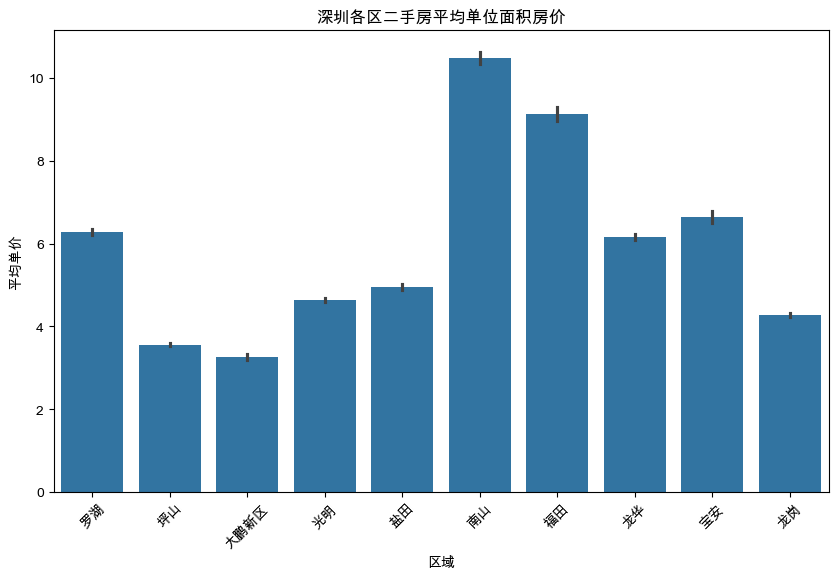

In [111]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="district", y="per_price", estimator=np.mean)
plt.title("深圳各区二手房平均单位面积房价")
plt.xlabel("区域")
plt.ylabel("平均单价")
plt.xticks(rotation=45)
plt.show()

## 地铁和学区对房价的影响
- 箱线图显示，靠近地铁的房源整体单位面积房价高于不靠近地铁的房源，说明交通便利性可能会带来一定的房价溢价。地铁因素不仅影响日常通勤，也会影响房源的流动性和市场吸引力。

- 学区房的单位面积房价也整体高于非学区房，说明教育资源是影响深圳二手房价格的重要因素之一。不过，学区房和非学区房内部都存在较多离群点，说明房价还会受到区域、小区品质、面积、楼龄等其他因素共同影响。

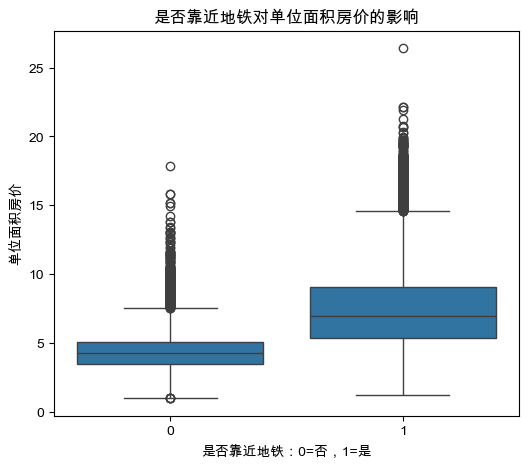

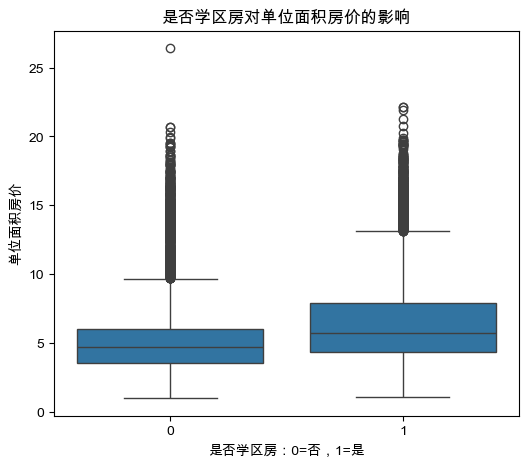

In [112]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="subway", y="per_price")
plt.title("是否靠近地铁对单位面积房价的影响")
plt.xlabel("是否靠近地铁：0=否，1=是")
plt.ylabel("单位面积房价")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="school", y="per_price")
plt.title("是否学区房对单位面积房价的影响")
plt.xlabel("是否学区房：0=否，1=是")
plt.ylabel("单位面积房价")
plt.show()

## 面积与单位面积房价关系
- 从面积与单位面积房价的散点图可以看出，房源面积和单位面积房价之间并不是简单的线性关系。大多数房源集中在中小面积区间，但不同面积段的单价分布差异较大。部分大面积房源单价较高，可能是因为其位于核心区域或属于高品质住宅；也有一些大面积房源单价较低，可能位于非核心区域。

- 因此，面积本身会影响房价，但不能单独解释房价差异，需要结合区域、地铁、学区、楼层等变量一起分析。

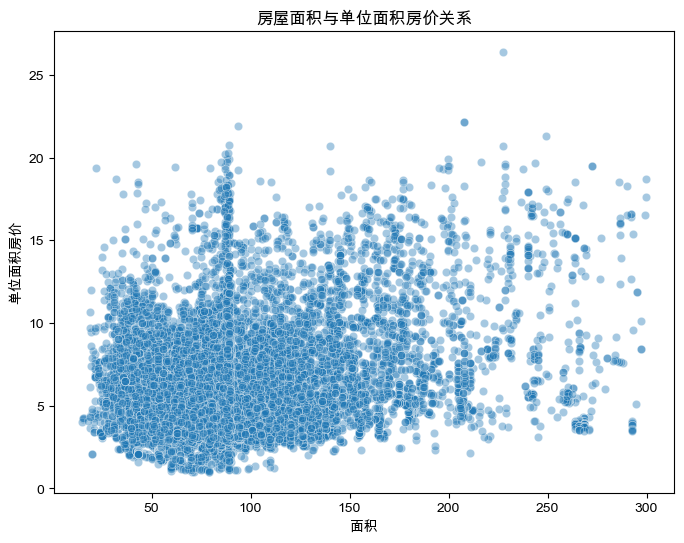

In [113]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="AREA", y="per_price", alpha=0.4)
plt.title("房屋面积与单位面积房价关系")
plt.xlabel("面积")
plt.ylabel("单位面积房价")
plt.show()

## 建模前处理
- 在建模阶段，本项目选择区域、房间数、厅数、面积、楼层类型、楼层数、是否学区房和是否靠近地铁作为特征变量，并以单位面积房价的对数作为预测目标。对单位面积房价取对数可以缓解房价分布偏态问题，使模型更稳定。

- 由于数据中同时包含数值变量和分类变量，本项目对数值变量进行标准化处理，对分类变量进行 One-Hot Encoding。随后将数据划分为训练集和测试集，用训练集训练模型，并用测试集评估模型表现。

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. 选择特征和目标变量
feature_cols = [
    "district", 
    "roomnum", 
    "hall", 
    "AREA", 
    "C_floor", 
    "floor_num", 
    "school", 
    "subway"
]

X = df[feature_cols]
y = df["log_per_price"]

In [115]:
# 2. 区分数值变量和分类变量
numeric_features = ["roomnum", "hall", "AREA", "floor_num", "school", "subway"]
categorical_features = ["district", "C_floor"]
# 不同版本的 scikit-learn 对 OneHotEncoder 的参数名称略有不同，这里做兼容处理
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# 数值变量标准化，分类变量做 One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", onehot, categorical_features)
    ]
)

# 划分训练集和测试集，保留 20% 数据用于模型评估
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 模型比较与评估
- 本项目比较了 Linear Regression、Ridge Regression、Random Forest 和 Gradient Boosting 四种模型，并使用 $R^2$、MAE 和 RMSE 作为评估指标。其中，$R^2$ 衡量模型对房价差异的解释能力，MAE 表示平均绝对误差，RMSE 对较大的预测误差更加敏感。

- 从测试集结果看，Random Forest 的表现最好，$R^2$ 为 $0.738$，MAE 为 $0.940$ 万元/平方米，RMSE 为 $1.524$ 万元/平方米。这说明随机森林模型能够解释约 $73.8%$ 的单位面积房价差异，平均预测误差约为 $0.94$ 万元/平方米。相比线性回归模型，随机森林能够更好地捕捉区域、面积、地铁和学区等变量之间的非线性关系。

In [116]:
# 比较线性模型和树模型，观察非线性模型是否更适合房价预测
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # 预测的是 log_per_price，需要转换回原始单价
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.exp(y_pred_log)
    y_true = np.exp(y_test)
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)

,Model,R2,MAE,RMSE
2,Random Forest,0.738284,0.939830,1.523884
3,Gradient Boosting,0.665212,1.107378,1.723540
1,Ridge Regression,0.607484,1.213161,1.866230
0,Linear Regression,0.607341,1.213364,1.866570


## 真实值与预测值对比
- 真实值与预测值散点图用于观察模型预测结果与实际房价之间的接近程度。图中的虚线代表理想情况下预测值等于真实值，如果散点越接近虚线，说明模型预测越准确。

- 从图中可以看出，大部分样本点分布在虚线附近，说明模型整体能够较好地捕捉深圳二手房单价的变化趋势。不过，在部分高价房源上仍然存在一定偏差，可能是因为原始数据中没有包含小区品质、楼龄、装修情况、具体商圈、景观资源等更细节的变量。

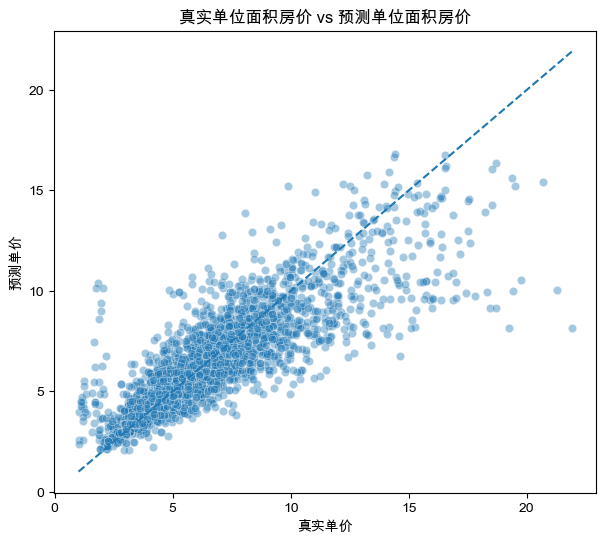

In [117]:
# 使用最佳模型做测试集预测
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

# 将预测值和真实值都从 log 尺度转换回万元/平方米
y_pred_log = best_model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.4)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle="--")
plt.title("真实单位面积房价 vs 预测单位面积房价")
plt.xlabel("真实单价")
plt.ylabel("预测单价")
plt.show()

## 残差分析
- 残差表示真实单位面积房价与预测单位面积房价之间的差异。本项目使用“真实单价 - 预测单价”计算残差。如果残差接近 $0$，说明模型预测较准确；如果残差为正，说明模型低估了房价；如果残差为负，说明模型高估了房价。

- 从残差分布图可以看出，大部分残差集中在 $0$ 附近，说明模型没有明显的系统性高估或低估问题。但残差分布仍然存在一定长尾，说明部分特殊房源的预测误差较大。这可能与数据中缺少小区等级、建筑年代、装修情况、朝向、学位质量等变量有关。

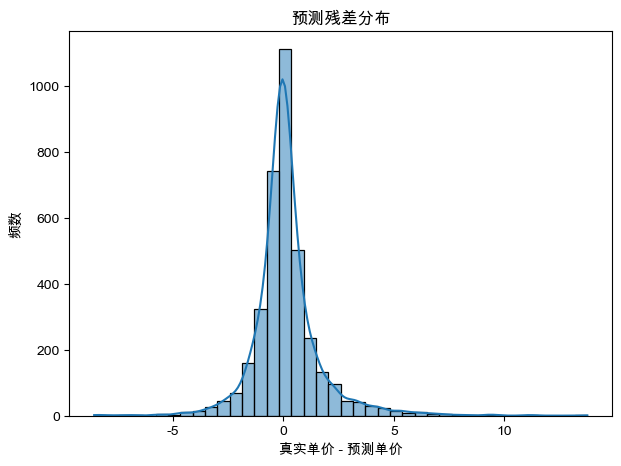

In [118]:
# 残差 = 真实单价 - 预测单价
# 残差为正表示模型低估房价，残差为负表示模型高估房价
residuals = y_true - y_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("预测残差分布")
plt.xlabel("真实单价 - 预测单价")
plt.ylabel("频数")
plt.show()

## 特征重要性分析
- 为了进一步解释模型结果，本项目使用 Random Forest 的特征重要性衡量不同变量对房价预测的贡献。结果显示，是否靠近地铁、是否位于南山区、房屋面积和楼层数是模型中较重要的预测因素。

- 其中，地铁变量的重要性最高，说明交通便利性在深圳二手房定价中具有较强影响。南山区变量的重要性也较高，与前面的区域均价分析一致，说明核心区域位置对房价具有明显溢价作用。面积和楼层数也对房价预测有一定贡献，说明房屋自身属性同样会影响单位面积房价。

,feature_clean,importance
5,是否靠近地铁,0.404601
7,是否位于南山,0.147332
2,房屋面积,0.111118
3,具体楼层数,0.078133
15,是否位于龙岗,0.062091
8,是否位于坪山,0.050105
9,是否位于大鹏新区,0.039915
12,是否位于福田,0.033970
4,是否学区房,0.017694
0,房间数,0.016832


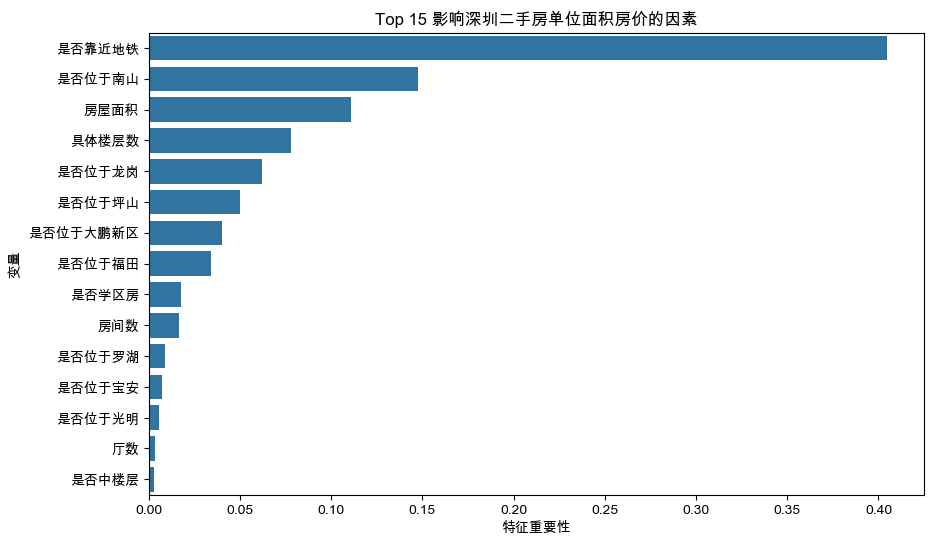

In [119]:
# 使用 Random Forest 分析特征重要性
rf_pipeline = trained_models["Random Forest"]

# 提取模型预处理后的变量名和对应的重要性
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# 将模型生成的变量名改成更容易理解的中文名称
feature_name_map = {
    "num__subway": "是否靠近地铁",
    "num__AREA": "房屋面积",
    "num__floor_num": "具体楼层数",
    "num__school": "是否学区房",
    "num__roomnum": "房间数",
    "num__hall": "厅数",
    "cat__district_南山": "是否位于南山",
    "cat__district_福田": "是否位于福田",
    "cat__district_罗湖": "是否位于罗湖",
    "cat__district_宝安": "是否位于宝安",
    "cat__district_龙岗": "是否位于龙岗",
    "cat__district_龙华": "是否位于龙华",
    "cat__district_坪山": "是否位于坪山",
    "cat__district_光明": "是否位于光明",
    "cat__district_盐田": "是否位于盐田",
    "cat__district_大鹏新区": "是否位于大鹏新区",
    "cat__C_floor_high": "是否高楼层",
    "cat__C_floor_middle": "是否中楼层",
    "cat__C_floor_low": "是否低楼层"
}

# 新建中文变量名列
importance_df["feature_clean"] = importance_df["feature"].replace(feature_name_map)

# 展示前 15 个重要特征
display(importance_df[["feature_clean", "importance"]].head(15))

plt.figure(figsize=(10, 6))

# 使用中文变量名画图，避免图中出现 num__、cat__ 这种机器生成的变量名
sns.barplot(data=importance_df.head(15), x="importance", y="feature_clean")

plt.title("Top 15 影响深圳二手房单位面积房价的因素")
plt.xlabel("特征重要性")
plt.ylabel("变量")
plt.show()

## 样本房源价格预测
- 最后，本项目使用表现最好的 Random Forest 模型对一个具体房源进行价格预测。假设该房源位于南山区，为 $3$ 房 $2$ 厅，面积 $80$ 平方米，高楼层，靠近地铁，并且属于学区房。模型预测其单位面积房价为 $9.39$ 万元/平方米，预测总价约为 $751.56$ 万元。

- 这个预测案例展示了模型的实际应用场景：在给定房源基本条件的情况下，可以快速估计房源的市场价格，为二手房估值、购房决策和市场分析提供参考。

In [120]:
# 选择测试集表现最好的模型用于样本房源估值
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("表现最好的模型是：", best_model_name)

# 构造一个假设房源：南山、3房2厅、80平方米、高楼层、近地铁、学区房
sample_house = pd.DataFrame({
    "district": ["南山"],
    "roomnum": [3],
    "hall": [2],
    "AREA": [80],
    "C_floor": ["high"],
    "floor_num": [20],
    "school": [1],
    "subway": [1]
})

# 先预测单位面积房价，再乘以面积得到总价
pred_log_price = best_model.predict(sample_house)
pred_per_price = np.exp(pred_log_price)[0]
pred_total_price = pred_per_price * sample_house.loc[0, "AREA"]

print("预测单位面积房价：", round(pred_per_price, 2), "万元/平方米")
print("预测总价：", round(pred_total_price, 2), "万元")

表现最好的模型是： Random Forest
预测单位面积房价： 9.39 万元/平方米
预测总价： 751.56 万元


## 项目总结
- 本项目基于深圳市多个行政区的二手房数据，完成了从数据读取、数据清洗、探索性数据分析到机器学习建模预测的完整流程。通过区域均价、箱线图和散点图分析可以发现，深圳二手房价格存在明显的区域差异，南山、福田等核心区域的平均单价明显高于其他区域；同时，是否靠近地铁、是否为学区房、面积和楼层等因素也与单位面积房价存在一定关系。

- 在建模部分，本项目比较了 Linear Regression、Ridge Regression、Random Forest 和 Gradient Boosting 四种模型。最终 Random Forest 表现最好，测试集 $R^2$ 为 $0.738$，MAE 为 $0.940$ 万元/平方米，RMSE 为 $1.524$ 万元/平方米，说明模型能够较好地解释深圳二手房单位面积房价的差异。

- 从特征重要性结果看，地铁、区域、面积和楼层数是影响房价预测的重要变量。最后，本项目使用最佳模型对一个南山区 $80$ 平方米、$3$ 房 $2$ 厅、近地铁、学区房的样本房源进行预测，得到预测单价 $9.39$ 万元/平方米，预测总价约 $751.56$ 万元。

- 本项目可以为二手房估值、区域价格比较和房地产市场分析提供一定的数据支持。未来如果能加入小区名称、楼龄、装修情况、朝向、具体商圈和成交时间等变量，模型预测效果有望进一步提升。